## 7.1 Introdução

As **equações diferenciais** constituem uma das aplicações mais importantes do cálculo. Essas equações relacionam uma função desconhecida com uma ou mais de suas derivadas e são utilizadas para descrever como uma grandeza varia em função de outra, normalmente em relação ao tempo ou ao espaço

As leis fundamentais da Física, como as da mecânica, do eletromagnetismo e da termodinâmica, são, em geral, formuladas a partir de observações empíricas que descrevem a evolução das propriedades físicas e dos estados dos sistemas. Em vez de expressarem diretamente o estado de um sistema, essas leis são normalmente formuladas em termos das variações espaciais e temporais das grandezas envolvidas, isto é, em termos de derivadas.

Alguns exemplos dessas leis são apresentados na tabela a seguir. 

| Lei | Expressão matemática | Variáveis e parámetros |
| :--- | :--- | :--- |
| Segunda lei de movimento de Newton | $\frac{d v}{d t}=\frac{F}{m}$ | Velocidade ( V ), força ( f ) e massa $(m)$ |
| Lei do calor de Fourier | $q=-k^{\prime} \frac{d T}{d x}$ | Fluxo de calor (q), condutividade térmico $\left(k^{\prime}\right)$ e temperatura ( 7 ) |
| Lei de difusão de Fick | $J=-D \frac{d c}{d x}$ | Fluxo de massa (), coeficiente de difusão ( $D$ ) e concentração (c) |
| Lei de Faraday (queda de tensão em um indutor) | $\Delta V_i=l \frac{d i}{d t}$ | Queda de tensão ( $\Delta V_{\mathrm{l}}$ ), indutância (L) e corrente (1) |

Em conjunto com os princípios de conservação da energia, da massa e da quantidade de movimento, essas leis dão origem a modelos matemáticos formulados como equações diferenciais. A resolução dessas equações permite obter funções que descrevem a evolução espacial e temporal de grandezas como velocidade, temperatura, concentração e energia (Chapra e Canale, 2016).

A importância dos métodos numéricos para a resolução de equações diferenciais ordinárias (EDOs) decorre do fato de que essas equações surgem com frequência na modelagem matemática de fenômenos em diversas áreas do conhecimento, como engenharia, física, química, biologia, economia e biomedicina.

De modo geral, problemas que relacionam uma função de uma variável com suas derivadas conduzem a uma equação diferencial ordinária. Em muitos casos, não é possível obter uma solução analítica para essas equações ou ela é excessivamente difícil de ser obtida. Nesses casos, recorre-se aos métodos numéricos, que fornecem aproximações da solução com precisão suficiente para aplicações práticas.

Uma equação diferencial ordinária é uma equação que relaciona uma função desconhecida de uma única variável independente, $y(x)$, com uma ou mais de suas derivadas em relação a essa variável.

A ordem de uma equação diferencial corresponde à maior ordem da derivada da função desconhecida presente na equação.

$$
y'=\frac{dy}{dx}, \qquad
y''=\frac{d^2y}{dx^2}, \qquad
\ldots
$$

A seguir, apresentam-se alguns exemplos de equações diferenciais ordinárias:

* $\displaystyle \frac{dy}{dx}=3x-1$ — EDO de primeira ordem;
* $\displaystyle y'=-xy$ — EDO de primeira ordem;
* $\displaystyle \frac{d^2y}{dx^2}=x^2-y+e^x$ — EDO de segunda ordem;
* $\displaystyle y''-4y'+3y=x$ — EDO de segunda ordem.

Resolver uma equação diferencial consiste em encontrar uma função $y(x)$ que, ao ser substituída na equação juntamente com suas derivadas, torne a igualdade verdadeira.

**Exemplo 7.1.1:** A equação diferencial $y' = -x y$ tem solução $ y = c \, e^{\frac{-x^2}{2}}$ com $c$ constante, pois 

$$ y' = c \, e^{\frac{-x^2}{2}}(-x) = -xy$$

ou seja, a função $y(x)$ satisfaz a equação. 

Podemos observar que esta equação apresenta infinitas soluções, pois, para cada valor diferente de $c$ temos uma solução particular diferente.

A seguir, vamos usar Python para plotar algumas das soluções, com a constante $c$ assumindo alguns valores entre 0 e 2. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(4,3)

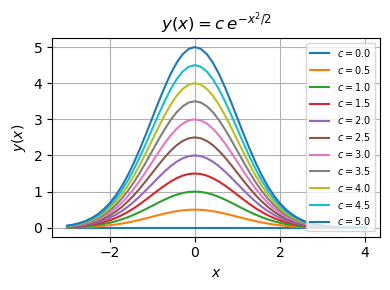

In [2]:
y = lambda x: c*np.exp((-x**2)/2)

xi = np.linspace(-3,4)

for c in np.arange(0,5.5,0.5):
    plt.plot(xi,y(xi),label=f"$c={c:.1f}$")

plt.xlabel("$x$")
plt.ylabel("$y(x)$")
plt.title(r"$y(x)=c\,e^{-x^2/2}$")
plt.grid(True)
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

**Exemplo 7.1.2:** A equação diferencial $\frac{du}{dt} = t + 2$ tem solução obtida facilmente integrando ambos os lados fazendo

$$ \int \frac{du}{dt}  = \int (t+2)dt $$

$$ u(t) = \frac{t^2}{2}+2t+k$$

em que $k$ é a constante de integração. Nesse caso a família de soluções, para $k=\{-1,0,1,3,5,7,10\}$ pode ser visualizada como é mostrado abaixo.


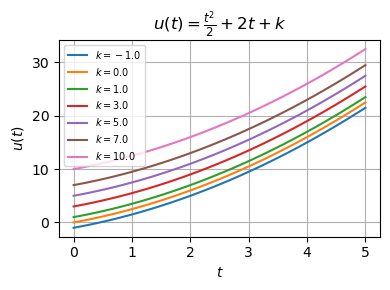

In [22]:
u = lambda t: (t**2/2)+2*t+k
t = np.linspace(0,5)

for k in [-1,0,1,3,5,7,10]:
    plt.plot(t,u(t),label=f"$k={k:.1f}$")

plt.xlabel("$t$")
plt.ylabel("$u(t)$")
plt.title(r"$u(t)=\frac{t^2}{2}+2t+k$")
plt.grid(True)
plt.legend(fontsize=7,loc="upper left")
plt.tight_layout()
plt.show()

Se impomos uma condição, como por exemplo $u(0)= 8$, obtemos o valor $k=8$, que restringe a solução a uma única curva e não mais à uma família de curvas. Uma equação diferencial com condições iniciais como essa compõem o que chamamos de um **problema de valor inicial (PVI)**. 

Ou seja, o problema de valor inicial descrito acima pode ser enunciado como

$$ 
\begin{cases} 
\frac {du}{dt}= t+2\\ 
\\
u(0)=8
\end{cases}$$

E existência e unicidade da solução de um PVI é garantida, sob certas condições, pelos teoremas *Condição de Lipschits*, *Pincard-Lindelof* e *Dependência contínua na condição inicial* enunciados e demonstrados em Medeiros e Oliveira (2020, p.24)

#### Resolução numérica de um PVI

Considere a equação diferencial ordinária, $y' = y$, cuja solução é dada por $y(x)=ce^x$, $c\in R$. Sabemos que essa equação diferencial apresenta infinitas soluções, uma vez que, para cada valor escolhido para a constante $c$, temos uma solução. 

Por exemplo, $y(x)=c_0e^x$, $y(x)=c_1e^x$, $y(x)=c_2e^x$, sendo $c_0$, $c_1$ , $c_2$ valores fixados, são soluções dessa equação conforme é ilustrado na figura abaixo.

![](https://raw.githubusercontent.com/tiagoburiol/metodos_numericos_em_python/refs/heads/main/7_EQUACOES_DIFERENCIAIS_ORDINARIAS/imagens/pvi01.png){width=360px}

Fonte: Arenales e Darezzo (2016)

Se conhecermos o valor da função $y(x)$ em um ponto $x = x_0$, ou seja, conhecermos $y_0$ etal que $y(x_0) = y_0$, então, podemos obter uma única solução para a equação proposta a partir da solução geral aplicando o ponto $x = x_0$ e obtendo o valor da constante $c$. Ou seja, fazemos

$$y(x)=ce^x \rightarrow ce^{x_0} = y_0 \rightarrow c=y_0e^{0-x_0} .$$ 


Assim, a solução única para a equação dada, juntamente com o valor inicial $y(x_0) = y_0$, é: 

$$y(x) = ce^x = y_0 e^{-x_0} e^x = y_0e^{(x-x_0)}$$

Portanto, $y(x) = y_0 e^{(x-x_0)}$, conforme exibido na figura.


Um **PVI de primeira ordem** consiste de uma equação diferencial $y' = f (x,y)$, $x \geq x_0$ e uma condição inicial $y(x_0) = y_0$, em que $y_0$ é um valor dado, chamado de valor inicial.

Neste caso, podemos escrever o PVI da seguinte forma:

$$ 
\begin{cases} 
y'= f(x,y)\\ 
\\
y(x_0)=y_0
\end{cases}$$

Resolver o PVI consiste em determinar uma função $y(x)$ que satisfaça a equação diferencial $y' = f (x,y)$ e a condição inicial $y(x_0) = y_0$. Se a função $f$ e $ \frac{\partial f}{\partial y}$ são contínuas, temos que o PVI apresenta solução única.



**Resolver numericamente um PVI** consiste em calcular aproximações para $y = y(x)$ em pontos discretos $x_0,x_1,x_2,\ldots,x_N$ de um intervalo $[a,b]$.

Para discretizar o intervalo $[a,b]$, tomamos $N$ subintervalos $(N \geq 1)$ e fazemos $x_n = x_0 + nh$, $n = 0,1,2,\ldots,N$ com $x_0 =a$ e $x_N =b$,sendo $h = (x_N −x_0)/N$.

A este conjunto de pontos $x_0,x_1,x_2,\ldots,x_N$ denominamos rede ou malha de pontos discretos, e calculamos aproximações para a função $y(x)$ nestes pontos, isto é, determinamos $y_n$ tal que $y_n \approx y(x_n)$, $n=0,1,\ldots,N$.

A partir de um ponto inicial dado $y(x_0) = y_0$ (valor inicial), calculamos passo a passo, nos pontos 

$$x_1 = x_0 +h,$$

$$x_2 = x_0 +2h,$$ 

$$x_3 = x_0 +3h,$$

$$\vdots$$

$$x_n = x_0 +nh$$ 

soluções aproximadas $y_n$ para a solução exata $y(x_n)$, $n=0,1,2,\ldots,N$, conforme ilustrado na figura a seguir.

![](https://raw.githubusercontent.com/tiagoburiol/metodos_numericos_em_python/refs/heads/main/7_EQUACOES_DIFERENCIAIS_ORDINARIAS/imagens/discretizacao.png){width=360px}

Nas seções seguintes serão estudados e implementados alguns dos principais métodos numéricos para a resolução de problemas de valor inicial (PVIs), como os métodos de Euler, Taylor e Runge-Kutta. Muitos desses métodos já estão implementados em bibliotecas computacionais e podem ser utilizados por meio de funções prontas. Como exemplo, a seguir é apresentada a utilização da função `solve_ivp`, disponível no módulo `scipy.integrate` da biblioteca SciPy (Virtanen et al., 2020), para resolver o PVI apresentado no Exemplo 7.1.2.

**Exemplo 7.1.3:** Resolução de um PVI **usando SciPy** ([Referência](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html#scipy.integrate.solve_ivp)):

In [23]:
from scipy.integrate import solve_ivp

def du(t, u):
    return t+2  

t0 = 0.0
tf = 5.0
u0 = [8]
t = np.linspace(t0,tf,20)

sol = solve_ivp(du, (t0,tf), u0, t_eval=t)
print(sol.y) 

[[ 8.          8.56094183  9.19113573  9.89058172 10.65927978 11.49722992
  12.40443213 13.38088643 14.4265928  15.54155125 16.72576177 17.97922438
  19.30193906 20.69390582 22.15512465 23.68559557 25.28531856 26.95429363
  28.69252078 30.5       ]]


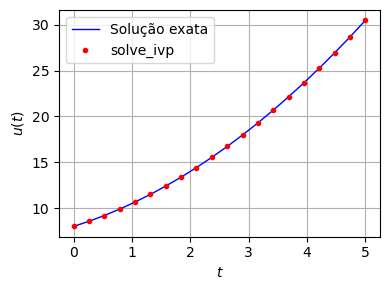

In [24]:
# Gráfico

u_exata = lambda t: (t**2/2)+2*t+8

plt.figure(figsize=(4,3))
plt.plot(t, u_exata(t), 'b-', lw=1, label='Solução exata')
plt.plot(sol.t, sol.y[0], 'r.', label='solve_ivp')

plt.xlabel('$t$')
plt.ylabel('$u(t)$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Exercícios

> **1.** Considere a equação diferencial
>
> $$\frac{du}{dt}=2t-e^{-t},$$
>
> cuja solução geral é
>
> $$u(t)=t^2+e^{-t}+C.$$
>
> a) Plote as soluções correspondentes a $C=-4,-2,0,2,4$.
>
> b) Resolva numericamente o problema de valor inicial
>
> $$> u(0)=2.$$
>
> c) Plote, no mesmo gráfico, a solução numérica e a solução analítica particular.

---

> **2.** Considere a equação diferencial
>
> $$> \frac{du}{dt}=3t^2+\cos(t),$$
>
> cuja solução geral é
>
> $$u(t)=t^3+\sin(t)+C.$$
>
> a) Plote as soluções correspondentes a $C=-6,-3,0,3,6$.
>
> b) Resolva numericamente o problema de valor inicial
>
> $$u(0)=1.$$
>
> c) Compare, em um mesmo gráfico, a solução numérica e a solução analítica.

---

> **3.** Considere a equação diferencial
>
> $$\frac{du}{dt}=e^t-2t,$$
>
> cuja solução geral é
>
> $$u(t)=e^t-t^2+C.$$
>
> a) Plote cinco soluções distintas da família de soluções.
>
> b) Resolva numericamente o problema de valor inicial
>
> $$u(0)=4.$$
>
> c) Compare a solução numérica com a solução analítica.

---

> **4.** Considere a equação diferencial
>
> $$\frac{du}{dt}=2\cos(2t)+3,$$
>
> cuja solução geral é
>
> $$u(t)=\sin(2t)+3t+C.$$
>
> a) Plote as soluções correspondentes a $C=-3,-1,1,3,5$.
>
> b) Resolva numericamente o problema de valor inicial
>
> $$u(0)=-2.$$
>
> c) Compare a solução numérica com a solução analítica.

---

> **5.** Considere a equação diferencial
>
> $$\frac{du}{dt}=\cos(t)+2t.$$
>
> a) Determine a solução geral da equação diferencial.
>
> b) Plote as soluções correspondentes a $C=-4,-2,0,2,4$.
>
> c) Resolva numericamente o problema de valor inicial
>
> $$u(0)=3.$$
>
> d) Compare a solução numérica com a solução analítica particular.

---

> **6.** Considere a equação diferencial
>
> $$\frac{du}{dt}=4t^3-e^{-t}.$$
> >
> a) Determine a solução geral da equação diferencial.
>
> b) Plote cinco soluções distintas da família de soluções.
>
> c) Resolva numericamente o problema de valor inicial
>
> $$u(0)=1.$$
>
> d) Compare a solução numérica com a solução analítica particular.

---

> **7.** Considere a equação diferencial
>
> $$\frac{du}{dt}=\frac{1}{1+t^2}+2.$$
>
> a) Determine a solução geral da equação diferencial.
>
> b) Plote as soluções correspondentes a $C=-3,-1,1,3,5$.
>
> c) Resolva numericamente o problema de valor inicial
>
> $$u(0)=0.$$
>
> d) Compare a solução numérica com a solução analítica particular.

---

> **8.** Considere a equação diferencial
>
> $$\frac{du}{dt}=2e^t-3\sin(t).$$
>
> a) Determine a solução geral da equação diferencial.
>
> b) Plote cinco soluções distintas da família de soluções.
>
> c) Resolva numericamente o problema de valor inicial
>
> $$u(0)=2.$$
>
> d) Compare a solução numérica com a solução analítica particular.

---

> **9.** Considere a equação diferencial
>
> $$\frac{du}{dt}=3t^2+2\cos(2t).$$
>
> a) Determine a solução geral da equação diferencial.
>
> b) Plote as soluções correspondentes a $C=-5,-2,0,2,5$.
>
> c) Resolva numericamente o problema de valor inicial
>
> $$u(0)=4.$$
>
> d) Compare a solução numérica com a solução analítica particular.

---

> **10.** Considere a equação diferencial
>
> $$\frac{du}{dt}=t^4-2t+\cos(t).$$
>
> a) Determine a solução geral da equação diferencial.
>
> b) Plote cinco soluções distintas da família de soluções.
>
> c) Resolva numericamente o problema de valor inicial
>
> $$u(0)=-1.$$
>
> d) Compare a solução numérica com a solução analítica particular.